In [1]:
import os
import sys

# Dynamic root path scoping
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.data_loader import load_insurance_data
from src.hypothesis_tests import test_numerical_margin, test_categorical_frequency

# Load the cleaned dataset state from task 2
df = load_insurance_data('../data/cleaned_insurance_data.csv')

# Explicitly cast structural target metrics
df['HasClaimed'] = (df['TotalClaims'] > 0).astype(int)
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

print("Data loaded and structured successfully!")

Data loaded and structured successfully!


=== Gender Chi-Square Test ===
Statistic: 0.0021
P-Value: 9.6383e-01
Reject Null Hypothesis? False



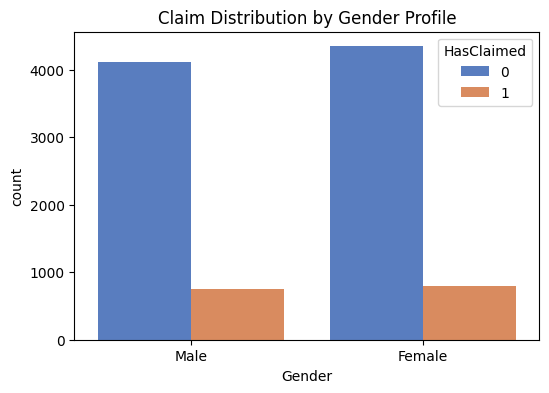

In [2]:
gender_res = test_categorical_frequency(df, 'Gender', 'HasClaimed')
print(f"=== Gender Chi-Square Test ===")
print(f"Statistic: {gender_res['statistic']:.4f}")
print(f"P-Value: {gender_res['p_value']:.4e}")
print(f"Reject Null Hypothesis? {gender_res['reject_h0']}\n")

# Visual Verification
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', hue='HasClaimed', palette='muted')
plt.title('Claim Distribution by Gender Profile')
plt.show()

In [3]:
# Select top 5 ZipCodes by concentration to ensure structural sampling stability
top_zipcodes = df['ZipCode'].value_counts().nlargest(5).index
filtered_zip_df = df[df['ZipCode'].isin(top_zipcodes)]

zip_res = test_categorical_frequency(filtered_zip_df, 'ZipCode', 'HasClaimed')
print(f"=== ZipCode Chi-Square Test ===")
print(f"Statistic: {zip_res['statistic']:.4f}")
print(f"P-Value: {zip_res['p_value']:.4e}")
print(f"Reject Null Hypothesis? {zip_res['reject_h0']}\n")

=== ZipCode Chi-Square Test ===
Statistic: 5.6036
P-Value: 2.3078e-01
Reject Null Hypothesis? False



Addis Ababa unique values count: 2056 (Total rows: 3567)
Oromia unique values count: 1558 (Total rows: 2446)

=== Province Margin Two-Sample T-Test ===
T-Statistic: 0.4519
P-Value: 6.5133e-01
Reject Null Hypothesis? False



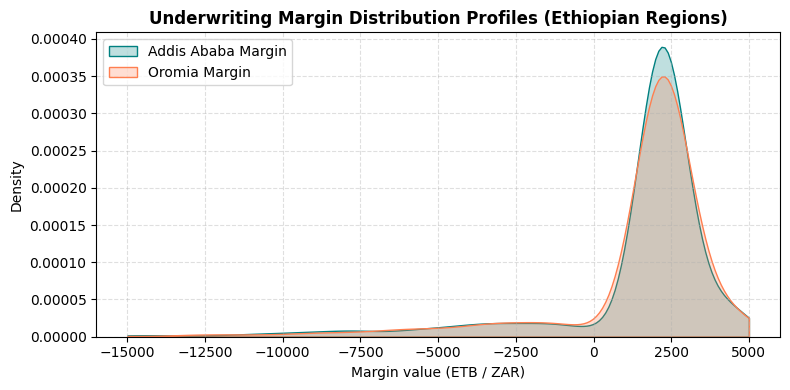

In [8]:
# 1. Enforce explicit calculation using your correct columns
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# 2. Filter using the actual Ethiopian regions from your dataset
addis_margin = df[df['Province'] == 'Addis Ababa']['Margin'].dropna()
oromia_margin = df[df['Province'] == 'Oromia']['Margin'].dropna()

print(f"Addis Ababa unique values count: {addis_margin.nunique()} (Total rows: {len(addis_margin)})")
print(f"Oromia unique values count: {oromia_margin.nunique()} (Total rows: {len(oromia_margin)})")

# 3. Safe execution of T-Test
if addis_margin.nunique() <= 1 or oromia_margin.nunique() <= 1:
    print("\n[WARNING] Data variance is zero or sample size too small. Check filters.")
else:
    margin_res = test_numerical_margin(addis_margin, oromia_margin)
    print(f"\n=== Province Margin Two-Sample T-Test ===")
    print(f"T-Statistic: {margin_res['statistic']:.4f}")
    print(f"P-Value: {margin_res['p_value']:.4e}")
    print(f"Reject Null Hypothesis? {margin_res['reject_h0']}\n")

    # 4. Safe Plotting with updated labels
    plt.figure(figsize=(8, 4))
    
    # Clip extreme outlier claims to make the main distribution waves clear and scannable
    sns.kdeplot(data=df[df['Province'] == 'Addis Ababa'], x='Margin', fill=True, color="teal", label="Addis Ababa Margin", clip=(-15000, 5000))
    sns.kdeplot(data=df[df['Province'] == 'Oromia'], x='Margin', fill=True, color="coral", label="Oromia Margin", clip=(-15000, 5000))
    
    plt.title('Underwriting Margin Distribution Profiles (Ethiopian Regions)', fontsize=12, fontweight='bold')
    plt.xlabel('Margin value (ETB / ZAR)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()